In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from opacus import PrivacyEngine

# Experiment parameters

In [53]:
# Set random seed for reproducibility
torch.manual_seed(0)

# Parameters
d = 10  # Dimensionality
n = 1250  # Number of data points
epochs = 10
learning_rate = 1e-1
batch_size = 32

# Data generation

In [54]:
# Generate synthetic data
mean = torch.zeros(d)  # Zero mean
cov = torch.eye(d)  # Standard Gaussian
data = torch.distributions.MultivariateNormal(mean, cov).sample((n,))
target = mean.repeat(n, 1)  # Our target is the true mean repeated

# Create DataLoader
dataset = TensorDataset(data, target)

# Split the dataset into training and validation
train_size = int(0.8 * n)  # 80% for training
val_size = n - train_size  # 20% for validation

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Display the sizes of each dataset for verification
print(f'Training dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')

Training dataset size: 1000
Validation dataset size: 250


# Model

In [55]:
# Define a simple linear model
class LinearModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, input_dim, bias=False)

        # Initialize weights to 1
        torch.nn.init.constant_(self.fc.weight, 1.0)

    def forward(self, x):
        return self.fc(x)

In [31]:
def train_dp_model(data_loader, epochs, learning_rate, max_grad_norm, epsilon):
    print(f'Running with maximum gradient norm: {max_grad_norm}')

    model = LinearModel(d)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Initialize Privacy Engine
    privacy_engine = PrivacyEngine()
    model, optimizer, data_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=data_loader,
        target_epsilon=epsilon,
        target_delta=1e-5,
        max_grad_norm=max_grad_norm,
        epochs=epochs,
    )

    criterion = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        print(f' - Iterate epoch: {epoch}')
        epoch_loss = 0
        for batch_data, batch_target in data_loader:
            optimizer.zero_grad()
            output = model(batch_data)
            loss = criterion(output, batch_target)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(data_loader)
        losses.append(avg_loss)

    return losses[-1]  # Return the final loss

In [72]:
def train_dp_model(train_loader, val_loader, epochs, learning_rate, max_grad_norm, epsilon):
    print(f'Running with maximum gradient norm: {max_grad_norm}')

    # Initialize model and optimizer
    model = LinearModel(d)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Initialize Privacy Engine
    privacy_engine = PrivacyEngine()
    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        target_epsilon=epsilon,
        target_delta=1e-5,
        max_grad_norm=max_grad_norm,
        epochs=epochs,
    )

    criterion = nn.MSELoss()
    train_losses = []
    val_losses = []

    # Training and validation loop
    for epoch in range(epochs):        
        # Training phase
        model.train()  # Set model to training mode
        epoch_train_loss = 0
        for batch_data, batch_target in train_loader:
            optimizer.zero_grad()
            output = model(batch_data)
            loss = criterion(output, batch_target)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()  # Set model to evaluation mode
        epoch_val_loss = 0
        with torch.no_grad():  # Disable gradient calculation for validation
            for val_data, val_target in val_loader:
                val_output = model(val_data)
                val_loss = criterion(val_output, val_target)
                epoch_val_loss += val_loss.item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')

    return train_losses[-1], val_losses[-1]  # Return the final losses

In [45]:
def plot_results(max_grad_norms, results, epsilon):
    plt.figure(figsize=(10, 6))
    plt.plot(max_grad_norms, results, label=f"Epsilon = {epsilon}", marker='o')
    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')

    min_mse = min(results)
    plt.title(f'Effect of Maximum Gradient Norm on Toy model (epsilon={epsilon}) (Min MSE: {min_mse:.04})')
    plt.legend()
    plt.savefig(f'temp/toy-model-epsilon-{epsilon}.png')
    plt.grid(True)
    plt.show()

In [77]:
def plot_results_combined(max_grad_norms, train_results_dict, val_results_dict):
    plt.figure(figsize=(12, 8))
    
    # Use a color map to ensure consistent colors for each epsilon
    colors = plt.cm.viridis(np.linspace(0, 1, len(train_results_dict)))

    for i, (epsilon, train_losses) in enumerate(train_results_dict.items()):
        val_losses = val_results_dict[epsilon]

        # Plot training losses with dotted lines
        plt.plot(max_grad_norms, train_losses, linestyle='--', color=colors[i], marker='o', label=f"Training Loss (ε = {epsilon})")
        
        # Plot validation losses with solid lines
        plt.plot(max_grad_norms, val_losses, linestyle='-', color=colors[i], marker='x', label=f"Validation Loss (ε = {epsilon})")

    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')
    plt.title('Effect of Maximum Gradient Norm on Toy Model')
    plt.legend()
    plt.grid(True)
    plt.ylim([0,5])
    plt.savefig(f'temp/toy-model-all-epsilons.png')
    plt.show()


Running for epsilon: 0.25
Running with maximum gradient norm: 0.0001
Epoch [1/10], Training Loss: 9.5547, Validation Loss: 5.9343
Epoch [2/10], Training Loss: 4.7189, Validation Loss: 2.8788
Epoch [3/10], Training Loss: 3.0343, Validation Loss: 2.6696
Epoch [4/10], Training Loss: 2.6812, Validation Loss: 2.3738
Epoch [5/10], Training Loss: 2.1524, Validation Loss: 1.7877
Epoch [6/10], Training Loss: 1.7594, Validation Loss: 1.6615
Epoch [7/10], Training Loss: 2.1764, Validation Loss: 2.4014
Epoch [8/10], Training Loss: 2.4101, Validation Loss: 2.2976
Epoch [9/10], Training Loss: 2.5849, Validation Loss: 2.3108
Epoch [10/10], Training Loss: 2.4626, Validation Loss: 2.6479
Running with maximum gradient norm: 0.00024616309676992636
Epoch [1/10], Training Loss: 10.0478, Validation Loss: 7.1208
Epoch [2/10], Training Loss: 7.8610, Validation Loss: 6.1982
Epoch [3/10], Training Loss: 6.7643, Validation Loss: 5.1817
Epoch [4/10], Training Loss: 5.2646, Validation Loss: 4.2218
Epoch [5/10], Tr

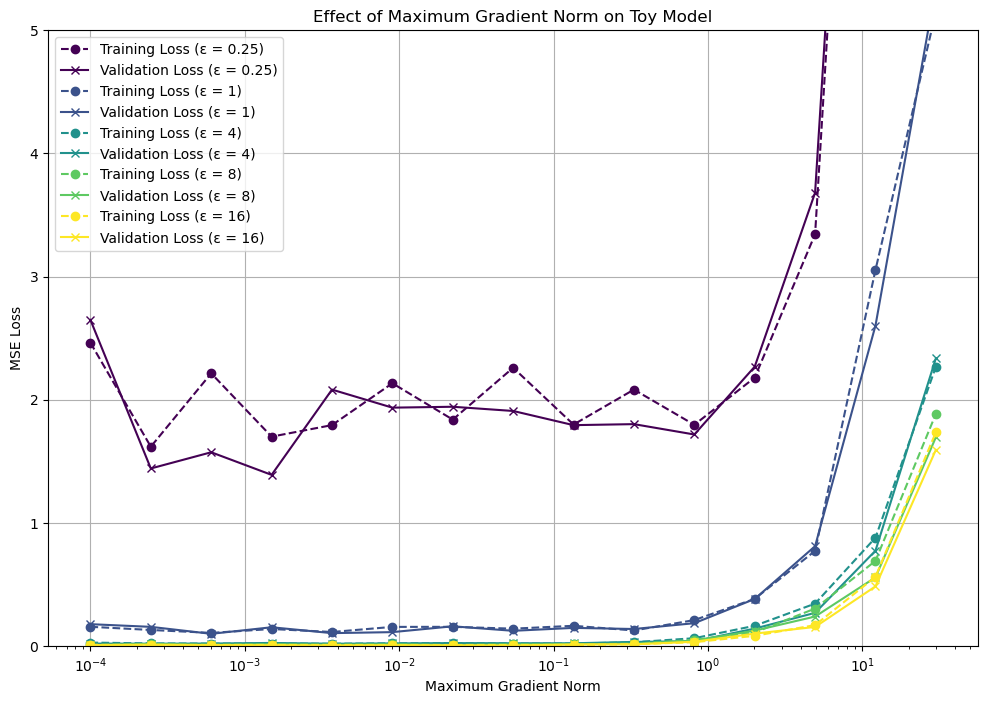

In [78]:
max_grad_norms = np.geomspace(1e-4, 30, 15)
epsilon_values = [0.25, 1, 4, 8, 16]

# Store results for all epsilon values
train_results_dict = {}
val_results_dict = {}

for epsilon in epsilon_values:
    print(f'Running for epsilon: {epsilon}')
    
    # Compute results for each max_grad_norm
    results = [
        train_dp_model(train_loader, val_loader, epochs=epochs, learning_rate=learning_rate, max_grad_norm=mgn, epsilon=epsilon)
        for mgn in max_grad_norms
    ]
    
    # Unpack results into separate lists for training and validation losses
    train_losses, val_losses = zip(*results)
    
    # Store the results in the dictionaries
    train_results_dict[epsilon] = train_losses
    val_results_dict[epsilon] = val_losses

# Plot all results in a single plot
plot_results_combined(max_grad_norms, train_results_dict, val_results_dict)